Saving data.csv to data (1).csv
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:


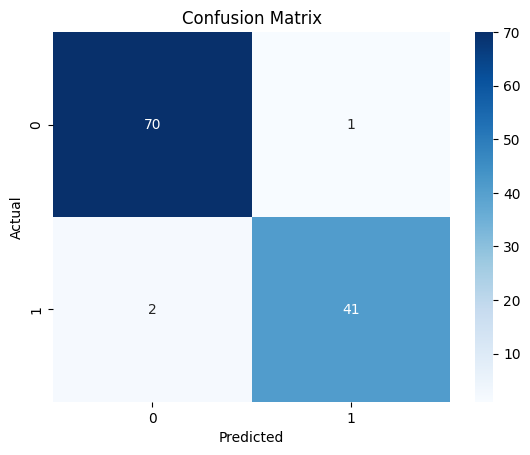

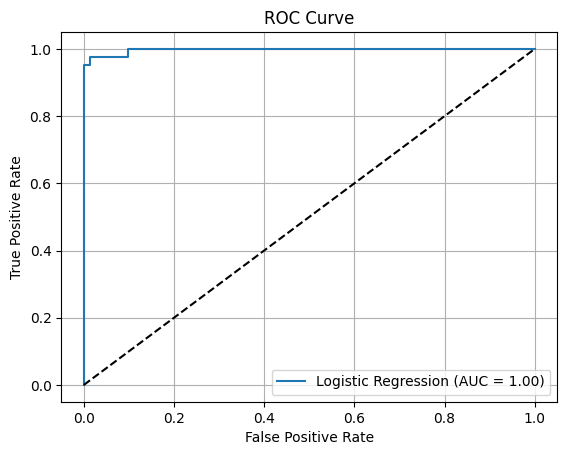

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset (manual upload for Google Colab)
from google.colab import files
uploaded = files.upload()

# Step 2: Read the CSV file (replace 'data.csv' with your actual file name if different)
df = pd.read_csv('data.csv')

# Step 3: Drop irrelevant columns
df = df.drop('id', axis=1)  # Drop 'id' if it exists

# Step 4: Encode the target variable ('diagnosis': B = 0, M = 1)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Step 5: Handle missing values (important for model training)
df = df.fillna(df.median(numeric_only=True))  # Replace NaN with column medians

# Step 6: Split features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Feature scaling (standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 9: Train Logistic Regression model
model = LogisticRegression(max_iter=1000)  # Increased iterations to ensure convergence
model.fit(X_train_scaled, y_train)

# Step 10: Make predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Step 11: Evaluation - Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 12: Evaluation - Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 13: ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
